In [ ]:
# Step 0: Install PySpark in Colab
!pip install pyspark

In [ ]:
# Step 1: Import Required Libraries
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Test_Spark").getOrCreate()
data = spark.createDataFrame([(1, "Sharline"), (2, "Mary")], ["ID", "Name"])
data.show()
spark.stop()

+---+--------+
| ID|    Name|
+---+--------+
|  1|Sharline|
|  2|    Mary|
+---+--------+



In [ ]:
# Start Spark
spark = SparkSession.builder.appName("Energy_Consumption_BigData").getOrCreate()

In [ ]:
# Install PySpark
!pip install pyspark

# Import libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofweek, avg
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import matplotlib.pyplot as plt

# Start Spark session
spark = SparkSession.builder.appName("Energy_Consumption_BigData").getOrCreate()

# Download the CSV file from URL
!wget -O airtravel.csv "https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv"

# Load CSV into PySpark DataFrame
data = spark.read.option("header", True).option("inferSchema", True).csv("/content/airtravel.csv")

# Check column names and first 5 rows
print(data.columns)
data.show(5)


--2025-10-26 11:33:26--  https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv
Resolving people.sc.fsu.edu (people.sc.fsu.edu)... 144.174.0.22
Connecting to people.sc.fsu.edu (people.sc.fsu.edu)|144.174.0.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 321 [text/csv]
Saving to: ‘airtravel.csv’

airtravel.csv       100%[===================>]     321  --.-KB/s    in 0s      

2025-10-26 11:33:26 (128 MB/s) - ‘airtravel.csv’ saved [321/321]

['Month', ' "1958"', ' "1959"', ' "1960"']
+-----+-------+-------+-------+
|Month| "1958"| "1959"| "1960"|
+-----+-------+-------+-------+
|  JAN|  340.0|  360.0|  417.0|
|  FEB|  318.0|  342.0|  391.0|
|  MAR|  362.0|  406.0|  419.0|
|  APR|  348.0|  396.0|  461.0|
|  MAY|  363.0|  420.0|  472.0|
+-----+-------+-------+-------+
only showing top 5 rows



In [ ]:
# Strip quotes and spaces from column names
new_columns = [c.replace('"', '').strip() for c in data.columns]
data = data.toDF(*new_columns)

# Check column names
print(data.columns)
data.show(5)

['Month', '1958', '1959', '1960']
+-----+-----+-----+-----+
|Month| 1958| 1959| 1960|
+-----+-----+-----+-----+
|  JAN|340.0|360.0|417.0|
|  FEB|318.0|342.0|391.0|
|  MAR|362.0|406.0|419.0|
|  APR|348.0|396.0|461.0|
|  MAY|363.0|420.0|472.0|
+-----+-----+-----+-----+
only showing top 5 rows



In [ ]:
# Step 7: Convert Year Columns to Float
for year in ['1958', '1959', '1960']:
    data = data.withColumn(year, col(year).cast('float'))

data.show(5)

+-----+-----+-----+-----+
|Month| 1958| 1959| 1960|
+-----+-----+-----+-----+
|  JAN|340.0|360.0|417.0|
|  FEB|318.0|342.0|391.0|
|  MAR|362.0|406.0|419.0|
|  APR|348.0|396.0|461.0|
|  MAY|363.0|420.0|472.0|
+-----+-----+-----+-----+
only showing top 5 rows



In [ ]:
from pyspark.sql.functions import when

# Define month order
month_order = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
               "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

# Create MonthIndex column
data = data.withColumn("MonthIndex",
                       when(col("Month") == month_order[0], 1)
                      .when(col("Month") == month_order[1], 2)
                      .when(col("Month") == month_order[2], 3)
                      .when(col("Month") == month_order[3], 4)
                      .when(col("Month") == month_order[4], 5)
                      .when(col("Month") == month_order[5], 6)
                      .when(col("Month") == month_order[6], 7)
                      .when(col("Month") == month_order[7], 8)
                      .when(col("Month") == month_order[8], 9)
                      .when(col("Month") == month_order[9], 10)
                      .when(col("Month") == month_order[10], 11)
                      .when(col("Month") == month_order[11], 12))

data.show(5)

+-----+-----+-----+-----+----------+
|Month| 1958| 1959| 1960|MonthIndex|
+-----+-----+-----+-----+----------+
|  JAN|340.0|360.0|417.0|         1|
|  FEB|318.0|342.0|391.0|         2|
|  MAR|362.0|406.0|419.0|         3|
|  APR|348.0|396.0|461.0|         4|
|  MAY|363.0|420.0|472.0|         5|
+-----+-----+-----+-----+----------+
only showing top 5 rows



In [ ]:
# Combine all years
data_long = data.select(col("MonthIndex"), col("1958").alias("Passengers")) \
    .union(data.select(col("MonthIndex"), col("1959").alias("Passengers"))) \
    .union(data.select(col("MonthIndex"), col("1960").alias("Passengers")))

data_long.show(5)

+----------+----------+
|MonthIndex|Passengers|
+----------+----------+
|         1|     340.0|
|         2|     318.0|
|         3|     362.0|
|         4|     348.0|
|         5|     363.0|
+----------+----------+
only showing top 5 rows



In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=["MonthIndex"], outputCol="features")
model_data = assembler.transform(data_long).select("features", "Passengers")

model_data.show(5)

+--------+----------+
|features|Passengers|
+--------+----------+
|   [1.0]|     340.0|
|   [2.0]|     318.0|
|   [3.0]|     362.0|
|   [4.0]|     348.0|
|   [5.0]|     363.0|
+--------+----------+
only showing top 5 rows



In [ ]:
from pyspark.ml.regression import LinearRegression

# Split into train and test sets
train_data, test_data = model_data.randomSplit([0.8, 0.2], seed=42)

# Train Linear Regression
lr = LinearRegression(featuresCol='features', labelCol='Passengers')
lr_model = lr.fit(train_data)

# Evaluate model
test_results = lr_model.evaluate(test_data)
print("RMSE:", test_results.rootMeanSquaredError)
print("R²:", test_results.r2)

RMSE: 77.04962421419823
R²: -0.06197701338451833


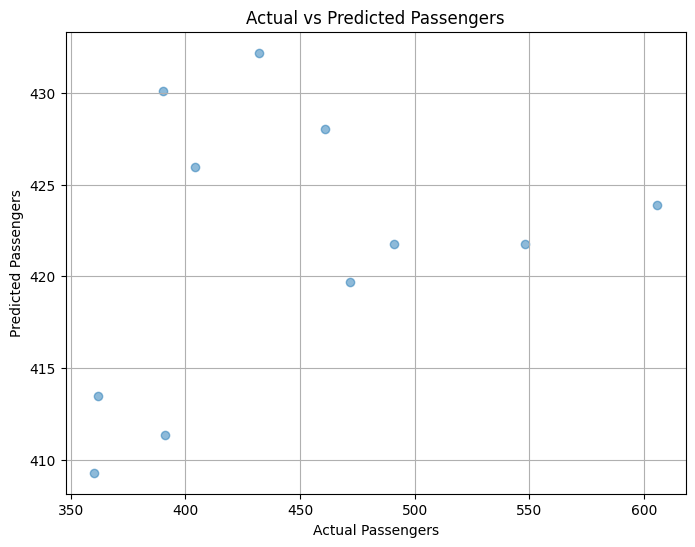

In [ ]:
# Get predictions
predictions = lr_model.transform(test_data)
pred_pd = predictions.select("Passengers", "prediction").toPandas()

# Plot actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pred_pd["Passengers"], pred_pd["prediction"], alpha=0.5)
plt.xlabel("Actual Passengers")
plt.ylabel("Predicted Passengers")
plt.title("Actual vs Predicted Passengers")
plt.grid(True)
plt.show()

In [ ]:
spark.stop()